<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<style>
  * { box-sizing: border-box; margin: 0; padding: 0; }
.card {
    font-family: system-ui, -apple-system, sans-serif;
    width: 100%;
    border-radius: 10px;
    overflow: hidden;
    box-shadow: 0 4px 12px rgba(0,0,0,0.12);
    border: 1px solid #e5e7eb;
    background: #fcfcfd;
    }
.card-header {
    background-color: #121826;
    padding: 16px 20px 14px;
  }
.lab-label {
    color: #9ca3af;
    font-size: 11px;
    font-weight: 600;
    letter-spacing: 1.5px;
    text-transform: uppercase;
    margin-bottom: 10px;
  }
.title-row {
    display: flex;
    align-items: center;
    gap: 10px;
    flex-wrap: wrap;
    margin-bottom: 5px;
  }
.exp-badge {
    background-color: #22c55e;
    color: #022c22;
    font-weight: 700;
    font-size: 12px;
    padding: 3px 12px;
    border-radius: 9999px;
    white-space: nowrap;
    flex-shrink: 0;
  }
.card-title {
    color: #ffffff;
    font-size: 18px;
    font-weight: 700;
    line-height: 1.3;
  }
.card-subtitle {
    color: #94a3b8;
    font-size: 13px;
  }
.card-body {
    padding: 14px 20px 18px;
  }
.info-row {
    display: grid;
    grid-template-columns: 1fr 1fr;
    align-items: center;
    padding: 10px 0;
    border-bottom: 1px dashed #cbd5e1;
  }
.info-row:last-of-type {
    border-bottom: none;
  }
.info-label {
    color: #475569;
    font-weight: 600;
    font-size: 13px;
  }
.info-value {
    color: #0f172a;
    font-weight: 700;
    font-size: 13px;
    text-align: right;
  }
.note-box {
    background-color: #e0f2fe;
    color: #0369a1;
    padding: 12px 16px;
    border-radius: 8px;
    font-size: 13px;
    line-height: 1.6;
    margin-top: 14px;
  }
</style>
</head>
<body style="padding: 10px; background: transparent;">

<div class="card">

  <div class="card-header">
    <div class="lab-label">Machine Learning Lab</div>
    <div class="title-row">
      <span class="exp-badge">EXP 06</span>
      <span class="card-title">Credit Card Default Risk using SVM</span>
    </div>
    <div class="card-subtitle">Support Vector Machine — Binary Classification</div>
  </div>

  <div class="card-body">
    <div class="info-row">
      <span class="info-label">Student Name</span>
      <span class="info-value">Manav Lakhani</span>
    </div>
    <div class="info-row">
      <span class="info-label">Class / Roll No. / Batch</span>
      <span class="info-value">SE-AIML / 35 / A2</span>
    </div>
    <div class="info-row">
      <span class="info-label">Subject</span>
      <span class="info-value">Machine Learning Lab</span>
    </div>
    <div class="info-row">
      <span class="info-label">Date of Performance</span>
      <span class="info-value">05/03/2026</span>
    </div>
<div class="note-box">
      This experiment focuses on applying Support Vector Machines (SVM) to classify credit card default risk using financial datasets.
    </div>
  </div>

</div>

</body>
</html>

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , confusion_matrix , precision_score , recall_score , f1_score
from sklearn.svm import SVC

In [21]:
data = pd.read_csv("credit.csv",skiprows=1)
data = data.sample(5000,random_state=42)
print(data.columns)
data.drop(columns=["ID"] , inplace = True)
print(data.columns)

Index(['ID', 'LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')
Index(['LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')


In [22]:
data.head()

,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
2308,30000,1,2,2,25,0,0,0,0,0,...,12580,13716,14828,1500,2000,1500,1500,1500,2000,0
22404,150000,2,1,2,26,0,0,0,0,0,...,101581,77741,77264,4486,4235,3161,2647,2669,2669,0
23397,70000,2,3,1,32,0,0,0,0,0,...,69753,70111,70212,2431,3112,3000,2438,2500,2554,0
25058,130000,1,3,2,49,0,0,0,0,0,...,16898,11236,6944,1610,1808,7014,27,7011,4408,0
2664,50000,2,2,2,36,0,0,0,0,0,...,19574,20295,19439,2000,1500,1000,1800,0,1000,1


In [23]:
data.tail()

,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
6778,180000,1,1,2,27,0,0,0,0,0,...,16908,37319,34978,19000,5000,10009,22000,20000,15000,0
25284,50000,2,2,2,22,0,0,0,0,0,...,52198,43181,31473,2000,2000,10052,2000,1136,2000,0
18355,200000,2,1,2,24,-2,-2,-2,-2,-2,...,500,2057,23322,1053,0,500,2057,23322,4299,0
27684,120000,2,2,2,24,0,0,0,0,0,...,53216,49194,48487,2000,2600,4241,1700,2500,1500,0
4110,90000,2,2,1,29,0,0,0,0,0,...,4173,4408,5846,1522,3010,1500,1500,1500,2000,0


In [24]:
data.isnull().sum()

LIMIT_BAL                     0
GENDER                        0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [25]:
data.shape

(5000, 24)

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 2308 to 4110
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   5000 non-null   int64
 1   GENDER                      5000 non-null   int64
 2   EDUCATION                   5000 non-null   int64
 3   MARRIAGE                    5000 non-null   int64
 4   AGE                         5000 non-null   int64
 5   PAY_0                       5000 non-null   int64
 6   PAY_2                       5000 non-null   int64
 7   PAY_3                       5000 non-null   int64
 8   PAY_4                       5000 non-null   int64
 9   PAY_5                       5000 non-null   int64
 10  PAY_6                       5000 non-null   int64
 11  BILL_AMT1                   5000 non-null   int64
 12  BILL_AMT2                   5000 non-null   int64
 13  BILL_AMT3                   5000 non-null   int64
 14  BILL_AMT4 

In [27]:
y = data['default payment next month']
x = data[['BILL_AMT1','BILL_AMT2']]
print(x.dtypes)
print(x.head())

BILL_AMT1    int64
BILL_AMT2    int64
dtype: object
       BILL_AMT1  BILL_AMT2
2308        8864      10062
22404     136736     125651
23397      70122      69080
25058      20678      18956
2664       94228      47635


In [28]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.3 , random_state=42)

In [29]:
scaler = StandardScaler()
x_train= scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [30]:
models={
    "Linear SVM" : SVC(kernel='linear', C=1 , class_weight='balanced'),
    "Polynomial SVM " : SVC ( kernel = 'poly',
                              degree = 2,
                              C=1,
                              
                              gamma = 'scale',
                              class_weight = 'balanced'),
    "RBF SVM" : SVC(kernel='rbf',
                    C=1,gamma=0.1,class_weight='balanced')
}

for name , model in models.items():
    model.fit(x_train , y_train)
    y_pred=model.predict(x_test)

    
    y_pred_train=model.predict(x_train)

    print("\n",name)
    print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
    print("Precision:",precision_score(y_test,y_pred , zero_division=0))
    print("Recall:",recall_score(y_test,y_pred))
    print("F1 Score:",f1_score(y_test, y_pred))
    print("Accuracy Score Test:",accuracy_score(y_test, y_pred))
    print("Accuracy Score Train:",accuracy_score(y_pred_train, y_train))


 Linear SVM
Confusion Matrix:
 [[ 103 1056]
 [  34  307]]
Precision: 0.2252384446074835
Recall: 0.9002932551319648
F1 Score: 0.36032863849765256
Accuracy Score Test: 0.2733333333333333
Accuracy Score Train: 0.2797142857142857

 Polynomial SVM 
Confusion Matrix:
 [[  35 1124]
 [   8  333]]
Precision: 0.22855181880576528
Recall: 0.9765395894428153
F1 Score: 0.3704115684093437
Accuracy Score Test: 0.24533333333333332
Accuracy Score Train: 0.24114285714285713

 RBF SVM
Confusion Matrix:
 [[499 660]
 [138 203]]
Precision: 0.23522595596755505
Recall: 0.5953079178885631
F1 Score: 0.3372093023255814
Accuracy Score Test: 0.468
Accuracy Score Train: 0.464


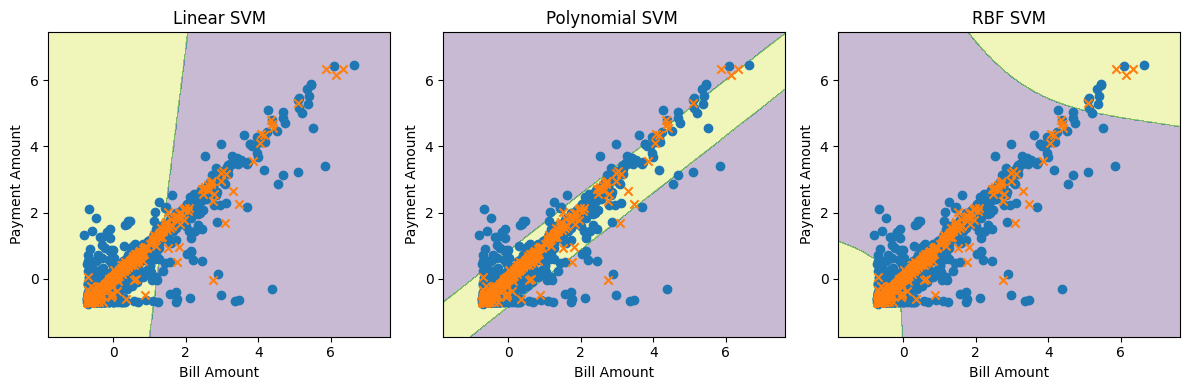

In [31]:
def plot_boundary(model,title):
    h=0.02
    x_min , x_max = x_train[:,0].min()-1,x_train[:,0].max()+1
    y_min , y_max= x_train[:,1].min()-1,x_train[:,1].max()+1

    xx ,yy = np.meshgrid(
        np.arange(x_min ,x_max ,h),
        np.arange(y_min ,y_max ,h)
    )


    Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx,yy,Z,alpha=0.3)
    
    plt.scatter(x_train[y_train==0,0],
               x_train[y_train==0,1],
               label='No Default (0)',
               marker='o')
    plt.scatter(x_train[y_train==1,0],
               x_train[y_train==1,1],
               label='Default (1)',
               marker='x')
    plt.title(title)
    plt.xlabel("Bill Amount")
    plt.ylabel("Payment Amount")
plt.figure(figsize=(12,4))

for i ,(name,model)in enumerate (models.items()):
    plt.subplot(1,3,i+1)
    model.fit(x_train,y_train)
    plot_boundary(model,name)

plt.tight_layout()
plt.show()